# Agriculture Health - Data Engineering Notebook

**Course:** ISB46703 Principle of Artificial Intelligence  
**Role:** Data Engineer  
**Domain:** Agriculture Health  
**Task:** Plant leaf disease image classification

This notebook documents the full data engineering workflow: web crawling, filtering, pre-processing, train/validation/test splitting, counting, and final verification.

Final cleaned dataset after manual filtering, exact duplicate removal, visual review, and class balancing: **5,750 images** across **5 classes**.


## 0. Run Jupyter from the Correct Conda Environment

Open Anaconda Prompt or PowerShell and run:

```powershell
conda activate ISB46703
jupyter notebook
```

Then open this notebook.

## 1. Install / Check Required Packages

Run this cell once. If all packages are already installed, it will finish quickly.

In [1]:
%pip install icrawler pillow imagehash tqdm pandas scikit-learn matplotlib

Note: you may need to restart the kernel to use updated packages.


In [1]:
from pathlib import Path
import os
import shutil
import random
import hashlib
from collections import defaultdict

import pandas as pd
from PIL import Image, ImageFile
import imagehash
from tqdm import tqdm
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

ImageFile.LOAD_TRUNCATED_IMAGES = True
random.seed(42)

print('Packages imported successfully.')

Packages imported successfully.


## 2. Project Setup

We use 5 classes. Our original target was up to 10,000 images, but after manual filtering, exact duplicate removal, visual review, and class balancing, the final clean dataset contains 5,750 images.

| Class | Meaning | Final Total After Manual Cleaning |
|---|---|---:|
| yellow_leaf_disease | Yellowing/chlorotic diseased leaf | 1,150 |
| leaf_rust | Rust disease on leaves | 1,150 |
| powdery_mildew | White powdery mildew disease | 1,150 |
| leaf_spot | Spot disease on leaves | 1,150 |
| leaf_blight | Blight disease on leaves | 1,150 |

Because web crawling can collect wrong or duplicate images, the raw collection was larger than the final clean dataset. Obvious wrong images were removed manually before the final dataset was accepted.


In [2]:
PROJECT_ROOT = Path('..').resolve()
DATA_DIR = PROJECT_ROOT / 'data'
RAW_DIR = DATA_DIR / 'raw'
PROCESSED_DIR = DATA_DIR / 'processed'
CLEANED_DIR = DATA_DIR / 'cleaned'
FINAL_DIR = DATA_DIR / 'final'
REPORTS_DIR = PROJECT_ROOT / 'reports'

CLASSES = [
    'yellow_leaf_disease',
    'leaf_rust',
    'powdery_mildew',
    'leaf_spot',
    'leaf_blight',
]

RAW_TARGET_MIN_PER_CLASS = 1000
RAW_TARGET_MAX_PER_CLASS = 3000
FINAL_TARGET_PER_CLASS = 1150  
IMAGE_SIZE = (224, 224)

for base_dir in [RAW_DIR, PROCESSED_DIR, CLEANED_DIR]:
    for class_name in CLASSES:
        (base_dir / class_name).mkdir(parents=True, exist_ok=True)

for split in ['train', 'val', 'test']:
    for class_name in CLASSES:
        (FINAL_DIR / split / class_name).mkdir(parents=True, exist_ok=True)

REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print('Project root:', PROJECT_ROOT)
print('Folder setup completed.')

Project root: C:\Users\User\Desktop\AI\Github_Upload_Agriculture_Health_AI_Project\Data_Engineer
Folder setup completed.


## 3. Web Crawler Keywords

This section uses a web crawler to collect images from search results.

In [7]:
SEARCH_KEYWORDS = {
    'yellow_leaf_disease': [
        'Yellowing/chlorotic diseased leaf close up',
        'plant leaves turning yellow disease close up',
        'yellow chlorotic plant leaf symptoms close up',
    ],
    'leaf_rust': [
        'plant leaf rust disease close up',
        'crop leaf rust disease symptoms',
        'rust spots on plant leaves close up',
    ],
    'powdery_mildew': [
        'powdery mildew leaf disease close up',
        'white powder fungus on plant leaves',
        'powdery mildew crop disease leaf',
    ],
    'leaf_spot': [
        'plant leaf spot disease close up',
        'brown spots on plant leaves disease',
        'crop leaf spot disease symptoms',
    ],
    'leaf_blight': [
        'plant leaf blight disease close up',
        'crop leaf blight disease symptoms',
        'brown blight on plant leaves close up',
    ],
}


SEARCH_KEYWORDS

{'yellow_leaf_disease': ['Yellowing/chlorotic diseased leaf close up',
  'plant leaves turning yellow disease close up',
  'yellow chlorotic plant leaf symptoms close up'],
 'leaf_rust': ['plant leaf rust disease close up',
  'crop leaf rust disease symptoms',
  'rust spots on plant leaves close up'],
 'powdery_mildew': ['powdery mildew leaf disease close up',
  'white powder fungus on plant leaves',
  'powdery mildew crop disease leaf'],
 'leaf_spot': ['plant leaf spot disease close up',
  'brown spots on plant leaves disease',
  'crop leaf spot disease symptoms'],
 'leaf_blight': ['plant leaf blight disease close up',
  'crop leaf blight disease symptoms',
  'brown blight on plant leaves close up']}

## 4. Collect Raw Images Using Web Crawler

This project uses `icrawler` with Bing Image Search to collect plant disease images. The crawler was executed multiple times in separate batches until each class had enough raw images.

The `images_per_keyword` value was adjusted between crawler batches based on the number of additional images required for each class. A smaller value was used when a class was close to its target, while a larger value was used when more images were still needed.

A different run folder name, such as `run_01`, `run_02`, and later `run_19`, was used for every batch. This prevented new downloads from overwriting previous images and allowed the raw images from all crawler batches to accumulate inside `data/raw`.


In [8]:
from icrawler.builtin import BingImageCrawler

RAW_DIR.mkdir(parents=True, exist_ok=True)

def clean_folder_name(text):
    return (
        text.lower()
        .replace(' ', '_')
        .replace('/', '_')
        .replace('\\', '_')
        .replace(':', '_')
        .replace('-', '_')
    )[:50]

def crawl_class_images(class_name, keywords, images_per_keyword=100, run_name='run_19'):
    class_dir = RAW_DIR / class_name / run_name
    class_dir.mkdir(parents=True, exist_ok=True)

    for i, keyword in enumerate(keywords, start=1):
        keyword_dir = class_dir / f'keyword_{i}_{clean_folder_name(keyword)}'
        keyword_dir.mkdir(parents=True, exist_ok=True)

        print(f'Crawling {class_name}: {keyword}')
        print(f'Saving to: {keyword_dir}')

        crawler = BingImageCrawler(storage={'root_dir': str(keyword_dir)})
        crawler.crawl(keyword=keyword, max_num=images_per_keyword)

    print(f'Done: {class_name}')

IMAGES_PER_KEYWORD_PER_RUN = 100
for class_name in CLASSES:
    crawl_class_images(
        class_name,
        SEARCH_KEYWORDS[class_name],
        images_per_keyword=IMAGES_PER_KEYWORD_PER_RUN,
        run_name='run_19'
    )


2026-06-12 15:34:16,757 - INFO - icrawler.crawler - start crawling...
2026-06-12 15:34:16,758 - INFO - icrawler.crawler - starting 1 feeder threads...
2026-06-12 15:34:16,761 - INFO - feeder - thread feeder-001 exit
2026-06-12 15:34:16,765 - INFO - icrawler.crawler - starting 1 parser threads...
2026-06-12 15:34:16,769 - INFO - icrawler.crawler - starting 1 downloader threads...


Crawling yellow_leaf_disease: Yellowing/chlorotic diseased leaf close up
Saving to: C:\Users\User\Desktop\AI\Github_Upload_Agriculture_Health_AI_Project\Data_Engineer\data\raw\yellow_leaf_disease\run_19\keyword_1_yellowing_chlorotic_diseased_leaf_close_up


2026-06-12 15:34:17,084 - INFO - parser - parsing result page https://www.bing.com/images/async?q=Yellowing/chlorotic diseased leaf close up&first=0
2026-06-12 15:34:17,305 - INFO - parser - parsing result page https://www.bing.com/images/async?q=Yellowing/chlorotic diseased leaf close up&first=20
2026-06-12 15:34:17,542 - INFO - parser - parsing result page https://www.bing.com/images/async?q=Yellowing/chlorotic diseased leaf close up&first=40
2026-06-12 15:34:17,643 - INFO - downloader - image #1	http://eromitai.com/wordpress/wp-content/uploads/2014/04/marvelous_nude008.jpg
2026-06-12 15:34:17,757 - INFO - downloader - image #2	https://c8.alamy.com/comp/T1KWFE/talent-search-line-icon-concept-talent-search-flat-vector-symbol-sign-outline-illustration-T1KWFE.jpg
2026-06-12 15:34:17,757 - INFO - parser - parsing result page https://www.bing.com/images/async?q=Yellowing/chlorotic diseased leaf close up&first=60
2026-06-12 15:34:17,851 - INFO - downloader - image #3	https://i.pinimg.com/7

Crawling yellow_leaf_disease: plant leaves turning yellow disease close up
Saving to: C:\Users\User\Desktop\AI\Github_Upload_Agriculture_Health_AI_Project\Data_Engineer\data\raw\yellow_leaf_disease\run_19\keyword_2_plant_leaves_turning_yellow_disease_close_up


2026-06-12 15:34:38,292 - INFO - parser - parsing result page https://www.bing.com/images/async?q=plant leaves turning yellow disease close up&first=0
2026-06-12 15:34:38,709 - INFO - downloader - image #1	https://cafeplanta.com/cdn/shop/files/pothos-plant.jpg
2026-06-12 15:34:38,743 - INFO - downloader - image #2	https://cafeplanta.com/cdn/shop/files/8_ZAMIOCULCAS_ZAMIFOLIA_TEMP_3.12.24.jpg
2026-06-12 15:34:38,959 - INFO - downloader - image #3	https://a-z-animals.com/media/2023/03/Hyacinth-Bulbs-02.jpg
2026-06-12 15:34:39,463 - INFO - downloader - image #4	https://images.pexels.com/photos/31191509/pexels-photo-31191509.jpeg?cs=srgb&dl=pexels-optical-chemist-340351297-31191509.jpg
2026-06-12 15:34:39,822 - INFO - downloader - image #5	https://images.pexels.com/photos/1403398/pexels-photo-1403398.jpeg?cs=srgb&dl=green-plant-1403398.jpg
2026-06-12 15:34:40,123 - INFO - downloader - image #6	https://www.mydomaine.com/thmb/_PytGbxb73DzvV2uFjBOcJ_5XvE=/2121x0/filters:no_upscale():strip_icc

...

Crawling leaf_blight: crop leaf blight disease symptoms
Saving to: C:\Users\User\Desktop\AI\Github_Upload_Agriculture_Health_AI_Project\Data_Engineer\data\raw\leaf_blight\run_19\keyword_2_crop_leaf_blight_disease_symptoms


2026-06-12 15:38:00,042 - INFO - parser - parsing result page https://www.bing.com/images/async?q=crop leaf blight disease symptoms&first=0
2026-06-12 15:38:00,316 - INFO - parser - parsing result page https://www.bing.com/images/async?q=crop leaf blight disease symptoms&first=20
2026-06-12 15:38:00,985 - INFO - downloader - image #1	https://pyxis.nymag.com/v1/imgs/f3e/4a4/9e0ea8689721b609d337358f13a40077b8-17-kobe-bryant-vanessa-139176771.rvertical.w330.jpg
2026-06-12 15:38:02,717 - INFO - downloader - image #2	https://img1.daumcdn.net/thumb/S1200x630/?fname=https://t1.daumcdn.net/news/202403/08/chosunbiz/20240308122925795sdzd.jpg
2026-06-12 15:38:02,990 - ERROR - downloader - Response status code 400, file https://media.istockphoto.com/id/1484328296/ko/사진/투이-새-뉴질랜드-남섬의-서해안에있는-웨스트-랜드의-타이-푸-티니-국립-공원.jpg
2026-06-12 15:38:03,200 - ERROR - downloader - Response status code 400, file https://media.istockphoto.com/id/1125876530/ko/사진/마-오리-언어로-방울-anthornis-melanura-makomako.jpg
2026-06-12 15

Crawling leaf_blight: brown blight on plant leaves close up
Saving to: C:\Users\User\Desktop\AI\Github_Upload_Agriculture_Health_AI_Project\Data_Engineer\data\raw\leaf_blight\run_19\keyword_3_brown_blight_on_plant_leaves_close_up


2026-06-12 15:38:20,202 - INFO - parser - parsing result page https://www.bing.com/images/async?q=brown blight on plant leaves close up&first=0
2026-06-12 15:38:20,414 - INFO - parser - parsing result page https://www.bing.com/images/async?q=brown blight on plant leaves close up&first=20
2026-06-12 15:38:20,657 - INFO - parser - parsing result page https://www.bing.com/images/async?q=brown blight on plant leaves close up&first=40
2026-06-12 15:38:20,910 - INFO - parser - parsing result page https://www.bing.com/images/async?q=brown blight on plant leaves close up&first=60
2026-06-12 15:38:21,200 - INFO - downloader - image #1	https://www.nttpc.co.jp/column/img/entry/data_center/data_center/thumb.jpg
2026-06-12 15:38:21,312 - INFO - downloader - image #2	https://m.media-amazon.com/images/I/61BMo+GiSmL._AC_.jpg
2026-06-12 15:38:26,079 - INFO - parser - parsing result page https://www.bing.com/images/async?q=brown blight on plant leaves close up&first=80
2026-06-12 15:38:26,430 - ERROR - 

Done: leaf_blight


## 5. Count Raw Images

This use after crawling to check whether each class has enough raw images.

In [3]:
IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

def count_images(folder):
    folder = Path(folder)
    return sum(
        1 for file in folder.rglob('*') 
        if file.suffix.lower() in IMAGE_EXTENSIONS
    )

raw_counts_df = pd.DataFrame(
    [
        {
            'class': class_name,
            'raw_image_count': count_images(RAW_DIR / class_name)
        }
        for class_name in CLASSES
    ]
)

raw_counts_df.loc[len(raw_counts_df)] = {
    'class': 'TOTAL',
    'raw_image_count': raw_counts_df['raw_image_count'].sum()
}

raw_counts_df

,class,raw_image_count
0,yellow_leaf_disease,1251
1,leaf_rust,1250
2,powdery_mildew,1260
3,leaf_spot,1247
4,leaf_blight,1302
5,TOTAL,6310


## 6. Remove Broken Images and Standardize to JPG 224x224

This cell reads images from `data/raw`, converts them to RGB JPG, resizes them to 224x224, and saves them into `data/processed`.

Broken images are skipped automatically.

In [9]:
def standardize_images_for_class(class_name, limit=None):
    source_dir = RAW_DIR / class_name
    target_dir = PROCESSED_DIR / class_name

    if target_dir.exists():
        shutil.rmtree(target_dir)
    target_dir.mkdir(parents=True, exist_ok=True)

    image_files = [file for file in source_dir.rglob('*') if file.suffix.lower() in IMAGE_EXTENSIONS]
    if limit is not None:
        image_files = image_files[:limit]

    saved = 0
    skipped = 0

    for image_path in tqdm(image_files, desc=f'Standardizing {class_name}'):
        try:
            with Image.open(image_path) as img:
                img = img.convert('RGB')
                img = img.resize(IMAGE_SIZE)
                output_path = target_dir / f'{class_name}_{saved:05d}.jpg'
                img.save(output_path, 'JPEG', quality=95)
                saved += 1
        except Exception:
            skipped += 1

    return {'class': class_name, 'saved': saved, 'skipped_broken': skipped}

preprocessing_results = pd.DataFrame([
    standardize_images_for_class(class_name)
    for class_name in CLASSES
])

preprocessing_results


Standardizing yellow_leaf_disease:   0%|          | 0/1251 [00:00<?, ?it/s]

Standardizing yellow_leaf_disease:   1%|▏         | 17/1251 [00:00<00:07, 167.80it/s]

Standardizing yellow_leaf_disease:   3%|▎         | 34/1251 [00:00<00:07, 162.19it/s]

Standardizing yellow_leaf_disease:   4%|▍         | 51/1251 [00:00<00:07, 164.06it/s]

Standardizing yellow_leaf_disease:   5%|▌         | 68/1251 [00:00<00:07, 165.11it/s]

...

Standardizing leaf_blight:  99%|█████████▉| 1288/1302 [00:16<00:00, 26.59it/s]

Standardizing leaf_blight:  99%|█████████▉| 1292/1302 [00:16<00:00, 29.37it/s]

Standardizing leaf_blight: 100%|█████████▉| 1299/1302 [00:16<00:00, 38.39it/s]

Standardizing leaf_blight: 100%|██████████| 1302/1302 [00:16<00:00, 77.23it/s]

,class,saved,skipped_broken
0,yellow_leaf_disease,1251,0
1,leaf_rust,1250,0
2,powdery_mildew,1260,0
3,leaf_spot,1247,0
4,leaf_blight,1302,0


## 7. Remove Exact Duplicate Images

This step removes exact duplicate files using SHA256 file hashing. Similar-looking images are not removed automatically here because plant disease images can naturally look alike. Visual duplicates, wrong labels, and low-quality images are handled in the manual filtering step.


In [10]:
def remove_exact_duplicates_for_class(class_name):
    class_dir = PROCESSED_DIR / class_name
    image_files = sorted(class_dir.glob('*.jpg'))
    seen_hashes = {}
    removed = 0
    kept = 0

    for image_path in tqdm(image_files, desc=f'Removing exact duplicates {class_name}'):
        try:
            file_hash = hashlib.sha256(image_path.read_bytes()).hexdigest()
            if file_hash in seen_hashes:
                image_path.unlink()
                removed += 1
            else:
                seen_hashes[file_hash] = image_path
                kept += 1
        except Exception:
            image_path.unlink(missing_ok=True)
            removed += 1

    return {'class': class_name, 'kept': kept, 'removed_exact_duplicates_or_bad': removed}

dedup_results = pd.DataFrame([
    remove_exact_duplicates_for_class(class_name)
    for class_name in CLASSES
])

dedup_results


Removing exact duplicates yellow_leaf_disease:   0%|          | 0/1251 [00:00<?, ?it/s]

Removing exact duplicates yellow_leaf_disease:  19%|█▊        | 233/1251 [00:00<00:00, 2324.53it/s]

Removing exact duplicates yellow_leaf_disease:  37%|███▋      | 466/1251 [00:00<00:00, 2242.42it/s]

Removing exact duplicates yellow_leaf_disease:  55%|█████▌    | 691/1251 [00:00<00:00, 2158.78it/s]

Removing exact duplicates yellow_leaf_disease:  73%|███████▎  | 911/1251 [00:00<00:00, 2173.42it/s]

...

Removing exact duplicates leaf_blight:  42%|████▏     | 550/1302 [00:00<00:00, 2711.70it/s]

Removing exact duplicates leaf_blight:  63%|██████▎   | 822/1302 [00:00<00:00, 2707.29it/s]

Removing exact duplicates leaf_blight:  84%|████████▍ | 1094/1302 [00:00<00:00, 2711.93it/s]

Removing exact duplicates leaf_blight: 100%|██████████| 1302/1302 [00:00<00:00, 2699.75it/s]

,class,kept,removed_exact_duplicates_or_bad
0,yellow_leaf_disease,1246,5
1,leaf_rust,1250,0
2,powdery_mildew,1260,0
3,leaf_spot,1247,0
4,leaf_blight,1302,0


## 8. Manual Filtering Checklist

After automatic preprocessing and duplicate removal, the images were manually reviewed. Images were removed if they were irrelevant, not plant leaves, wrong disease class, too blurry, very low quality, heavily watermarked, or visually duplicated.

After manual filtering and class balancing, the cleaned dataset contains:

- 5 classes
- 1,150 images per class
- 5,750 images overall

The manually filtered images are stored in `data/cleaned` before being split into train, validation, and test folders.


## 9. Create Final Dataset Split

The project target was a 70% training, 15% validation, and 15% testing split. After manual deletion of obvious wrong images, the final cleaned dataset is not perfectly balanced, but it remains within the lecturer requirement.

Final cleaned split:

- 4,060 training images
- 820 validation images
- 870 testing images
- 5,750 images overall


In [11]:
def clear_final_dataset():
    for split in ['train', 'val', 'test']:
        split_dir = FINAL_DIR / split
        for class_name in CLASSES:
            class_dir = split_dir / class_name
            if class_dir.exists():
                shutil.rmtree(class_dir)
            class_dir.mkdir(parents=True, exist_ok=True)

def create_final_dataset_split():
    clear_final_dataset()
    summary = []

    for class_name in CLASSES:
        source_dir = CLEANED_DIR / class_name
        images = sorted(source_dir.glob('*.jpg'))

        if len(images) != FINAL_TARGET_PER_CLASS:
            raise ValueError(f'{class_name} has {len(images)} cleaned images. Expected {FINAL_TARGET_PER_CLASS}.')

        train_files, temp_files = train_test_split(images, train_size=812, random_state=42, shuffle=True)
        val_files, test_files = train_test_split(temp_files, train_size=164, random_state=42, shuffle=True)

        split_map = {
            'train': train_files,
            'val': val_files,
            'test': test_files,
        }

        for split, files in split_map.items():
            target_dir = FINAL_DIR / split / class_name
            target_dir.mkdir(parents=True, exist_ok=True)

            for index, source_path in enumerate(files):
                target_path = target_dir / f'{class_name}_{split}_{index:04d}.jpg'
                shutil.copy2(source_path, target_path)

            summary.append({
                'class': class_name,
                'split': split,
                'image_count': len(files),
            })

    return pd.DataFrame(summary)

split_summary = create_final_dataset_split()
print('Final dataset split created from data/cleaned.')
split_summary


Final dataset split created from data/cleaned.


,class,split,image_count
0,yellow_leaf_disease,train,812
1,yellow_leaf_disease,val,164
2,yellow_leaf_disease,test,174
3,leaf_rust,train,812
4,leaf_rust,val,164
5,leaf_rust,test,174
6,powdery_mildew,train,812
7,powdery_mildew,val,164
8,powdery_mildew,test,174
9,leaf_spot,train,812


## 10. Final Dataset Summary for Report

In [12]:
def final_dataset_summary():
    rows = []
    for split in ['train', 'val', 'test']:
        for class_name in CLASSES:
            count = count_images(FINAL_DIR / split / class_name)
            rows.append({'split': split, 'class': class_name, 'image_count': count})
    summary_df = pd.DataFrame(rows)
    return summary_df

summary_df = final_dataset_summary()
summary_df

,split,class,image_count
0,train,yellow_leaf_disease,812
1,train,leaf_rust,812
2,train,powdery_mildew,812
3,train,leaf_spot,812
4,train,leaf_blight,812
5,val,yellow_leaf_disease,164
6,val,leaf_rust,164
7,val,powdery_mildew,164
8,val,leaf_spot,164
9,val,leaf_blight,164


In [13]:
pivot_summary = summary_df.pivot(index='class', columns='split', values='image_count')
pivot_summary['total'] = pivot_summary.sum(axis=1)
pivot_summary.loc['TOTAL'] = pivot_summary.sum(axis=0)
pivot_summary

split,test,train,val,total
class,,,,
leaf_blight,174,812,164,1150
leaf_rust,174,812,164,1150
leaf_spot,174,812,164,1150
powdery_mildew,174,812,164,1150
yellow_leaf_disease,174,812,164,1150
TOTAL,870,4060,820,5750


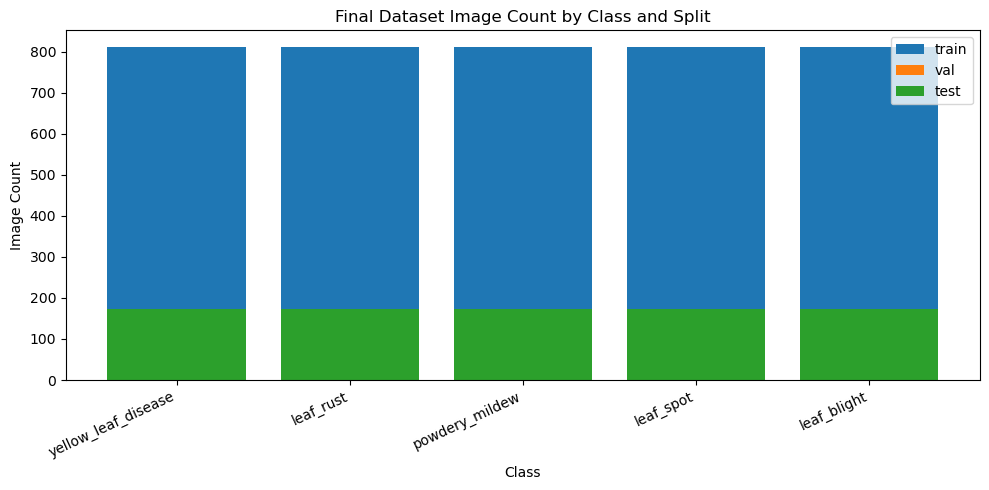

In [14]:
plot_df = summary_df.copy()
plt.figure(figsize=(10, 5))
for split in ['train', 'val', 'test']:
    split_df = plot_df[plot_df['split'] == split]
    plt.bar(split_df['class'], split_df['image_count'], label=split)

plt.title('Final Dataset Image Count by Class and Split')
plt.xlabel('Class')
plt.ylabel('Image Count')
plt.xticks(rotation=25, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

## 11. Technical File Check

This cell checks file readability and image size only. It does not prove that every image label is correct, because image relevance was checked manually.


In [15]:
def verify_final_dataset_from_notebook():
    rows = []
    issue_rows = []
    file_hashes = {}
    duplicate_rows = []

    for split in ['train', 'val', 'test']:
        for class_name in CLASSES:
            class_dir = FINAL_DIR / split / class_name
            image_files = sorted(class_dir.glob('*.jpg'))
            readable_files = 0
            unreadable_files = 0
            size_mismatch_files = 0
            for image_path in image_files:
                try:
                    file_hash = hashlib.sha256(image_path.read_bytes()).hexdigest()
                    if file_hash in file_hashes:
                        duplicate_rows.append({
                            'path': str(image_path),
                            'duplicate_of': file_hashes[file_hash],
                        })
                    else:
                        file_hashes[file_hash] = str(image_path)

                    with Image.open(image_path) as img:
                        if img.size != IMAGE_SIZE:
                            size_mismatch_files += 1
                            issue_rows.append({'path': str(image_path), 'issue': f'size_mismatch_{img.size}'})
                        readable_files += 1
                except Exception as exc:
                    unreadable_files += 1
                    issue_rows.append({'path': str(image_path), 'issue': repr(exc)})
            rows.append({
                'split': split,
                'class': class_name,
                'image_count': len(image_files),
                'readable_files': readable_files,
                'unreadable_files': unreadable_files,
                'size_mismatch_files': size_mismatch_files,
            })

    verification_df = pd.DataFrame(rows)
    issues_df = pd.DataFrame(issue_rows, columns=['path', 'issue'])
    duplicates_df = pd.DataFrame(duplicate_rows, columns=['path', 'duplicate_of'])
    return verification_df, issues_df, duplicates_df

verification_df, issues_df, duplicates_df = verify_final_dataset_from_notebook()
print('Issue count:', len(issues_df))
print('Duplicate count:', len(duplicates_df))
verification_df


Issue count: 0
Duplicate count: 0


,split,class,image_count,readable_files,unreadable_files,size_mismatch_files
0,train,yellow_leaf_disease,812,812,0,0
1,train,leaf_rust,812,812,0,0
2,train,powdery_mildew,812,812,0,0
3,train,leaf_spot,812,812,0,0
4,train,leaf_blight,812,812,0,0
5,val,yellow_leaf_disease,164,164,0,0
6,val,leaf_rust,164,164,0,0
7,val,powdery_mildew,164,164,0,0
8,val,leaf_spot,164,164,0,0
9,val,leaf_blight,164,164,0,0


## 12. Final Accepted Counts After Manual Cleaning

These are the final counts after manual deletion of obvious wrong images.

In [4]:
final_rows = []

for class_name in CLASSES:
    raw_count = count_images(RAW_DIR / class_name)
    cleaned_count = count_images(CLEANED_DIR / class_name)
    train_count = count_images(FINAL_DIR / 'train' / class_name)
    validation_count = count_images(FINAL_DIR / 'val' / class_name)
    test_count = count_images(FINAL_DIR / 'test' / class_name)

    final_rows.append({
        'class': class_name,
        'raw_count': raw_count,
        'cleaned_count': cleaned_count,
        'train': train_count,
        'validation': validation_count,
        'test': test_count,
        'total': train_count + validation_count + test_count,
    })

FINAL_ACCEPTED_COUNTS = pd.DataFrame(final_rows)

total_row = pd.DataFrame([{
    'class': 'TOTAL',
    'raw_count': FINAL_ACCEPTED_COUNTS['raw_count'].sum(),
    'cleaned_count': FINAL_ACCEPTED_COUNTS['cleaned_count'].sum(),
    'train': FINAL_ACCEPTED_COUNTS['train'].sum(),
    'validation': FINAL_ACCEPTED_COUNTS['validation'].sum(),
    'test': FINAL_ACCEPTED_COUNTS['test'].sum(),
    'total': FINAL_ACCEPTED_COUNTS['total'].sum(),
}])

final_accepted_summary = pd.concat([FINAL_ACCEPTED_COUNTS, total_row], ignore_index=True)
final_accepted_summary.to_csv(REPORTS_DIR / 'data_engineering_final_report.csv', index=False)
final_accepted_summary


,class,raw_count,cleaned_count,train,validation,test,total
0,yellow_leaf_disease,1251,1150,812,164,174,1150
1,leaf_rust,1250,1150,812,164,174,1150
2,powdery_mildew,1260,1150,812,164,174,1150
3,leaf_spot,1247,1150,812,164,174,1150
4,leaf_blight,1302,1150,812,164,174,1150
5,TOTAL,6310,5750,4060,820,870,5750
